# Práctica: Redes Convolucionales

## 0. Importación de librerías

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping


## 1. Lectura de imágenes y creación de datasets

In [2]:

IMG_SIZE = 32

train_dirs = [
    "data/github_train_0",
    "data/github_train_1",
    "data/github_train_2",
    "data/github_train_3"
]

test_dir = "data/github_test"


def get_label_from_filename(filename):
    name = filename.lower()
    if "cat" in name or "gato" in name:
        return 0
    if "dog" in name or "perro" in name:
        return 1
    raise ValueError(f"No se puede inferir clase desde {filename}")


def load_images_from_directory(directory):
    X = []
    y = []
    filenames = []

    for file in os.listdir(directory):
        path = os.path.join(directory, file)
        try:
            img = Image.open(path).convert("RGB")
            img = img.resize((IMG_SIZE, IMG_SIZE))
            img = np.array(img) / 255.0

            label = get_label_from_filename(file)

            X.append(img)
            y.append(label)
            filenames.append(file)
        except:
            pass

    return np.array(X), np.array(y), filenames


X_list = []
y_list = []

for d in train_dirs:
    X_tmp, y_tmp, _ = load_images_from_directory(d)
    X_list.append(X_tmp)
    y_list.append(y_tmp)

X_train = np.concatenate(X_list)
y_train = np.concatenate(y_list)

X_test, y_test, test_filenames = load_images_from_directory(test_dir)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (4000, 32, 32, 3)
Test shape: (1000, 32, 32, 3)


## 2. MiniEDA y visualización del dataset

Distribución clases train:
0    2000
1    2000
Name: count, dtype: int64


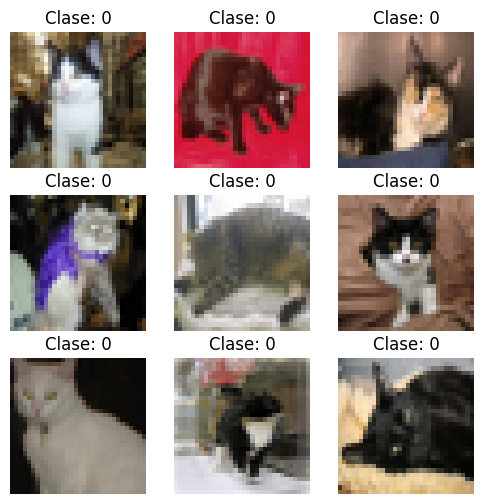

In [3]:

print("Distribución clases train:")
print(pd.Series(y_train).value_counts())


fig, axes = plt.subplots(3, 3, figsize=(6,6))

for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i])
    ax.set_title(f"Clase: {y_train[i]}")
    ax.axis("off")

plt.show()


## 3. Construcción del modelo CNN

In [4]:

model = models.Sequential([
    
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),
    
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


c:\Users\elnom\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 224,449 (876.75 KB)

 Trainable params: 224,449 (876.75 KB)

 Non-trainable params: 0 (0.00 B)

## 4. Entrenamiento con EarlyStopping

In [5]:

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)


Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6231 - loss: 0.6583 - val_accuracy: 0.0113 - val_loss: 0.8171
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6416 - loss: 0.6323 - val_accuracy: 0.2637 - val_loss: 0.9091
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6797 - loss: 0.6049 - val_accuracy: 0.1388 - val_loss: 1.0965
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6953 - loss: 0.5769 - val_accuracy: 0.3963 - val_loss: 0.8654
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7197 - loss: 0.5519 - val_accuracy: 0.6388 - val_loss: 0.6779
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7584 - loss: 0.5069 - val_accuracy: 0.3675 - val_loss: 0.8882
Epoch 7/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7697 - loss: 0.4752 - val_accuracy: 0.5312 - val_loss: 0.8485
Epoch 8/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8081 - loss: 0.4311 - val_accuracy: 0.

## Historial de entrenamiento

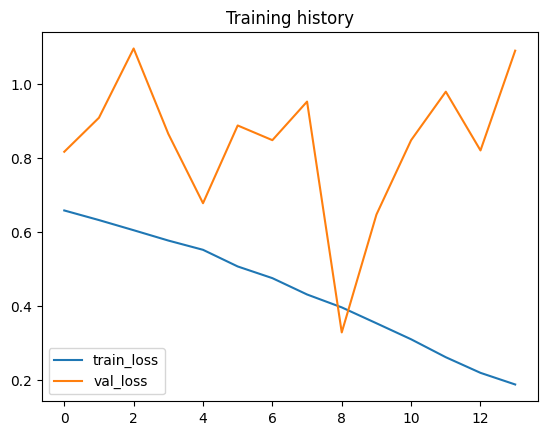

In [6]:

plt.figure()

plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')

plt.legend()
plt.title("Training history")
plt.show()


## 5. Evaluación del modelo

In [7]:

pred_probs = model.predict(X_test).flatten()
pred_labels = (pred_probs > 0.5).astype(int)

print(classification_report(y_test, pred_labels))

cm = confusion_matrix(y_test, pred_labels)
print("Confusion matrix")
print(cm)


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
              precision    recall  f1-score   support

           0       0.85      0.61      0.71       500
           1       0.70      0.90      0.78       500

    accuracy                           0.75      1000
   macro avg       0.78      0.75      0.75      1000
weighted avg       0.78      0.75      0.75      1000

Confusion matrix
[[305 195]
 [ 52 448]]


## 6. Selección de imágenes difíciles para CAPTCHA

In [8]:

df_results = pd.DataFrame({
    "filename": test_filenames,
    "true_label": y_test,
    "pred_label": pred_labels,
    "prob_dog": pred_probs
})

df_results["prob_cat"] = 1 - df_results["prob_dog"]

misclassified = df_results[df_results.true_label != df_results.pred_label]

dogs_as_cats = misclassified[(misclassified.true_label == 1) & (misclassified.pred_label == 0)]
cats_as_dogs = misclassified[(misclassified.true_label == 0) & (misclassified.pred_label == 1)]

dogs_as_cats = dogs_as_cats.sort_values("prob_dog", ascending=False)
cats_as_dogs = cats_as_dogs.sort_values("prob_cat", ascending=False)

n_select_dogs = max(1, int(len(dogs_as_cats) * 0.1))
n_select_cats = max(1, int(len(cats_as_dogs) * 0.1))

hard_dogs = dogs_as_cats.head(n_select_dogs)
hard_cats = cats_as_dogs.head(n_select_cats)

hard_images = pd.concat([hard_dogs, hard_cats])

print("Imágenes seleccionadas como CAPTCHA difíciles:")
display(hard_images)


Imágenes seleccionadas como CAPTCHA difíciles:


,filename,true_label,pred_label,prob_dog,prob_cat
619,dog.8533.jpg,1,0,0.491427,0.508573
870,dog.9447.jpg,1,0,0.487382,0.512618
869,dog.9440.jpg,1,0,0.486291,0.513709
598,dog.8451.jpg,1,0,0.484105,0.515895
653,dog.8676.jpg,1,0,0.480514,0.519486
244,cat.11519.jpg,0,1,0.501667,0.498333
313,cat.11720.jpg,0,1,0.502423,0.497577
467,cat.12221.jpg,0,1,0.502502,0.497498
357,cat.11855.jpg,0,1,0.503988,0.496012
202,cat.11359.jpg,0,1,0.504863,0.495137



Las imágenes seleccionadas son aquellas que:

- El modelo **clasifica incorrectamente**
- Pero **con alta confianza en la clase equivocada**

Estas son precisamente las más complicadas para un sistema automático, por lo que son buenas candidatas para el CAPTCHA.
